In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from glob import glob
import os
import seaborn as sns

In [62]:
paths = {
    "MSD-Heart+FIFO":"output/msd_task02+no_agent+icl+no_augment/2026-04-03-19-32-08/msd_Task02_agentFalse_ablation.csv",
    "MSD-Heart+AFS":"output/msd_task02+icl+ppo+skip_penalty+long_horizon+no_augment/2026-04-08-08-07-00/msd_Task02_agentTrue_ablation.csv",
}

In [63]:
dfs = {}

for l, p in paths.items():
    df = pd.read_csv(p, index_col=0)
    dfs[l] = df

In [64]:
# display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

In [65]:
for l, df in dfs.items():
    df["vol_id"] = df["id"].str.split("_").str[1].str.split(".").str[0].astype(np.int64)
    df["obj_id"] = df["id"].str.split("_").str[2].astype(np.int64)
    df["frame_id"] = df["id"].str.split("_").str[3].astype(np.int64)
    dfs[l] = df.set_index(["vol_id", "obj_id", "frame_id"])
    # dfs[l] = df.sort_values(["vol_id", "obj_id", "frame_id"])

In [76]:
display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

,,,id,delta,dice,drop_frame,drop_delta
vol_id,obj_id,frame_id,,,,,
7,1,58,la_007.nii.gz_1_58,"{57: 0.9404847621917725, 4: 0.9393188953399658...",0.940485,57,0.116587


In [67]:
for label, df in dfs.items():
    if "FIFO" in label:
        drop_delta = []
        for d, f in zip(df['delta'], df['drop_frame']):
            dices = eval(d)
            if f == -1:
                v = 0
            else:
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice) # drop agent choice - drop other choices => higher means better
                
                v = max(deltas)
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)
    else:
        drop_delta = []
        for frame_id, (d, f) in zip(df['id'], zip(df['delta'], df['drop_frame'])):
            if f == -1:
                v = 0
            else:
                dices = eval(d)
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice) # How much dropped frame more important than frame i

                if deltas:
                    v = max(deltas)
                else:
                    v = 0
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)

In [94]:
display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_011.nii.gz_1_58"])

,,,id,delta,dice,drop_frame,drop_delta
vol_id,obj_id,frame_id,,,,,
11,1,58,la_011.nii.gz_1_58,"{57: 0.531461775302887, 47: 0.6009345650672913...",0.600935,47,6.947279


In [ ]:
mean_delta = {}
for dataset in np.unique([k.split("+")[0] for k in dfs.keys()]):
    rl_df = dfs[dataset+"+AFS"]
    fifo_df = dfs[dataset+"+FIFO"]
    join_df = rl_df.join(fifo_df, on=["vol_id", "obj_id", "frame_id"], lsuffix="_rl", rsuffix="_fifo")
    join_df['dice_diff'] = (join_df['dice_rl'] - join_df['dice_fifo']) * 100
    join_df = join_df[join_df["drop_frame_fifo"] != -1]
    join_df = join_df[join_df['dice_diff'] > 0]
    # join_df = join_df[(join_df['dice_diff'] > join_df['dice_diff'].quantile(0.8))]
    
    # display(join_df)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(join_df.sort_values('dice_diff')[["dice_diff", "dice_rl", "dice_fifo", "id_rl", "id_fifo", "delta_rl", "delta_fifo", "drop_frame_rl", "drop_frame_fifo"]])
    # print(join_df.loc[pd.MultiIndex.from_tuples([(30,1,65)], names=["vol_id","obj_id","frame_id"])]['delta_rl'].values[0])
    
    mean_delta[dataset+"+FIFO"] = join_df["drop_delta_fifo"]
    mean_delta[dataset+"+AFS"] = join_df["drop_delta_rl"]
    
# display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

,,,id_rl,delta_rl,dice_rl,drop_frame_rl,drop_delta_rl,id_fifo,delta_fifo,dice_fifo,drop_frame_fifo,drop_delta_fifo
vol_id,obj_id,frame_id,,,,,,,,,,
7,1,58,la_007.nii.gz_1_58,"{57: 0.9404847621917725, 4: 0.9393188953399658...",0.940485,57,0.116587,la_007.nii.gz_1_58,"{57: 0.9122918844223022, 51: 0.912849843502044...",0.912523,51,0.055796


dice_diff   dice_rl  dice_fifo               id_rl  \
vol_id obj_id frame_id                                                       
7      1      19         0.002289  0.901495   0.901472  la_007.nii.gz_1_19   
30     1      26         0.020915  0.975537   0.975328  la_030.nii.gz_1_26   
              45         0.021333  0.947841   0.947628  la_030.nii.gz_1_45   
11     1      11         0.029451  0.874318   0.874023  la_011.nii.gz_1_11   
7      1      22         0.037634  0.952118   0.951742  la_007.nii.gz_1_22   
30     1      53         0.038368  0.950509   0.950125  la_030.nii.gz_1_53   
23     1      39         0.047362  0.931729   0.931256  la_023.nii.gz_1_39   
11     1      59         0.051087  0.373766   0.373255  la_011.nii.gz_1_59   
7      1      18         0.052381  0.883586   0.883062  la_007.nii.gz_1_18   
30     1      46         0.063974  0.944137   0.943497  la_030.nii.gz_1_46   
7      1      52         0.076556  0.954860   0.954094  la_007.nii.gz_1_52   
30     1      32         0.093472  0.975751   0.974817  la_030.nii.gz_1_32   
              37         0.095183  0.960182   0.959230  la_030.nii.gz_1_37   
              36         0.099188  0.967533   0.966542  la_030.nii.gz_1_36   
23     1      23         0.110739  0.967531   0.966424  la_023.nii.gz_1_23   
7      1      41         0.136411  0.968967   0.967603  la_007.nii.gz_1_41   
11     1      16         0.151145  0.915552   0.914041  la_011.nii.gz_1_16   
7      1      37         0.152725  0.970298   0.968771  la_007.nii.gz_1_37   
30     1      34         0.163901  0.975795   0.974156  la_030.nii.gz_1_34   
              35         0.167197  0.974124   0.972452  la_030.nii.gz_1_35   
              25         0.167942  0.975172   0.973492  la_030.nii.gz_1_25   
              33         0.171280  0.976579   0.974866  la_030.nii.gz_1_33   
              19         0.173700  0.968893   0.967156  la_030.nii.gz_1_19   
7      1      35         0.177497  0.967945   0.966170  la_007.nii.gz_1_35   
30     1      18         0.179470  0.968531   0.966736  la_030.nii.gz_1_18   
              27         0.184798  0.976751   0.974903  la_030.nii.gz_1_27   
23     1      43         0.191313  0.914734   0.912821  la_023.nii.gz_1_43   
30     1      21         0.192255  0.966567   0.964645  la_030.nii.gz_1_21   
              43         0.204611  0.967341   0.965295  la_030.nii.gz_1_43   
7      1      36         0.215346  0.967922   0.965769  la_007.nii.gz_1_36   
11     1      42         0.227338  0.939084   0.936811  la_011.nii.gz_1_42   
              18         0.240391  0.936169   0.933765  la_011.nii.gz_1_18   
7      1      42         0.309181  0.968214   0.965123  la_007.nii.gz_1_42   
30     1      44         0.311077  0.961917   0.958806  la_030.nii.gz_1_44   
              64         0.354737  0.655810   0.652263  la_030.nii.gz_1_64   
23     1      36         0.392270  0.946776   0.942853  la_023.nii.gz_1_36   
30     1      24         0.396836  0.976327   0.972358  la_030.nii.gz_1_24   
11     1      19         0.415295  0.949634   0.945481  la_011.nii.gz_1_19   
7      1      21         0.416082  0.958942   0.954781  la_007.nii.gz_1_21   
30     1      54         0.439876  0.941458   0.937059  la_030.nii.gz_1_54   
11     1      17         0.441706  0.919525   0.915108  la_011.nii.gz_1_17   
30     1      20         0.444883  0.961936   0.957487  la_030.nii.gz_1_20   
23     1      37         0.448704  0.928923   0.924436  la_023.nii.gz_1_37   
7      1      44         0.468504  0.967948   0.963263  la_007.nii.gz_1_44   
              20         0.477487  0.954814   0.950040  la_007.nii.gz_1_20   
11     1      43         0.492543  0.939028   0.934103  la_011.nii.gz_1_43   
30     1      22         0.523692  0.968647   0.963410  la_030.nii.gz_1_22   
              23         0.552231  0.970313   0.964790  la_030.nii.gz_1_23   
              47         0.560820  0.938248   0.932640  la_030.nii.gz_1_47   
23     1      35         0.569177  0.953891   

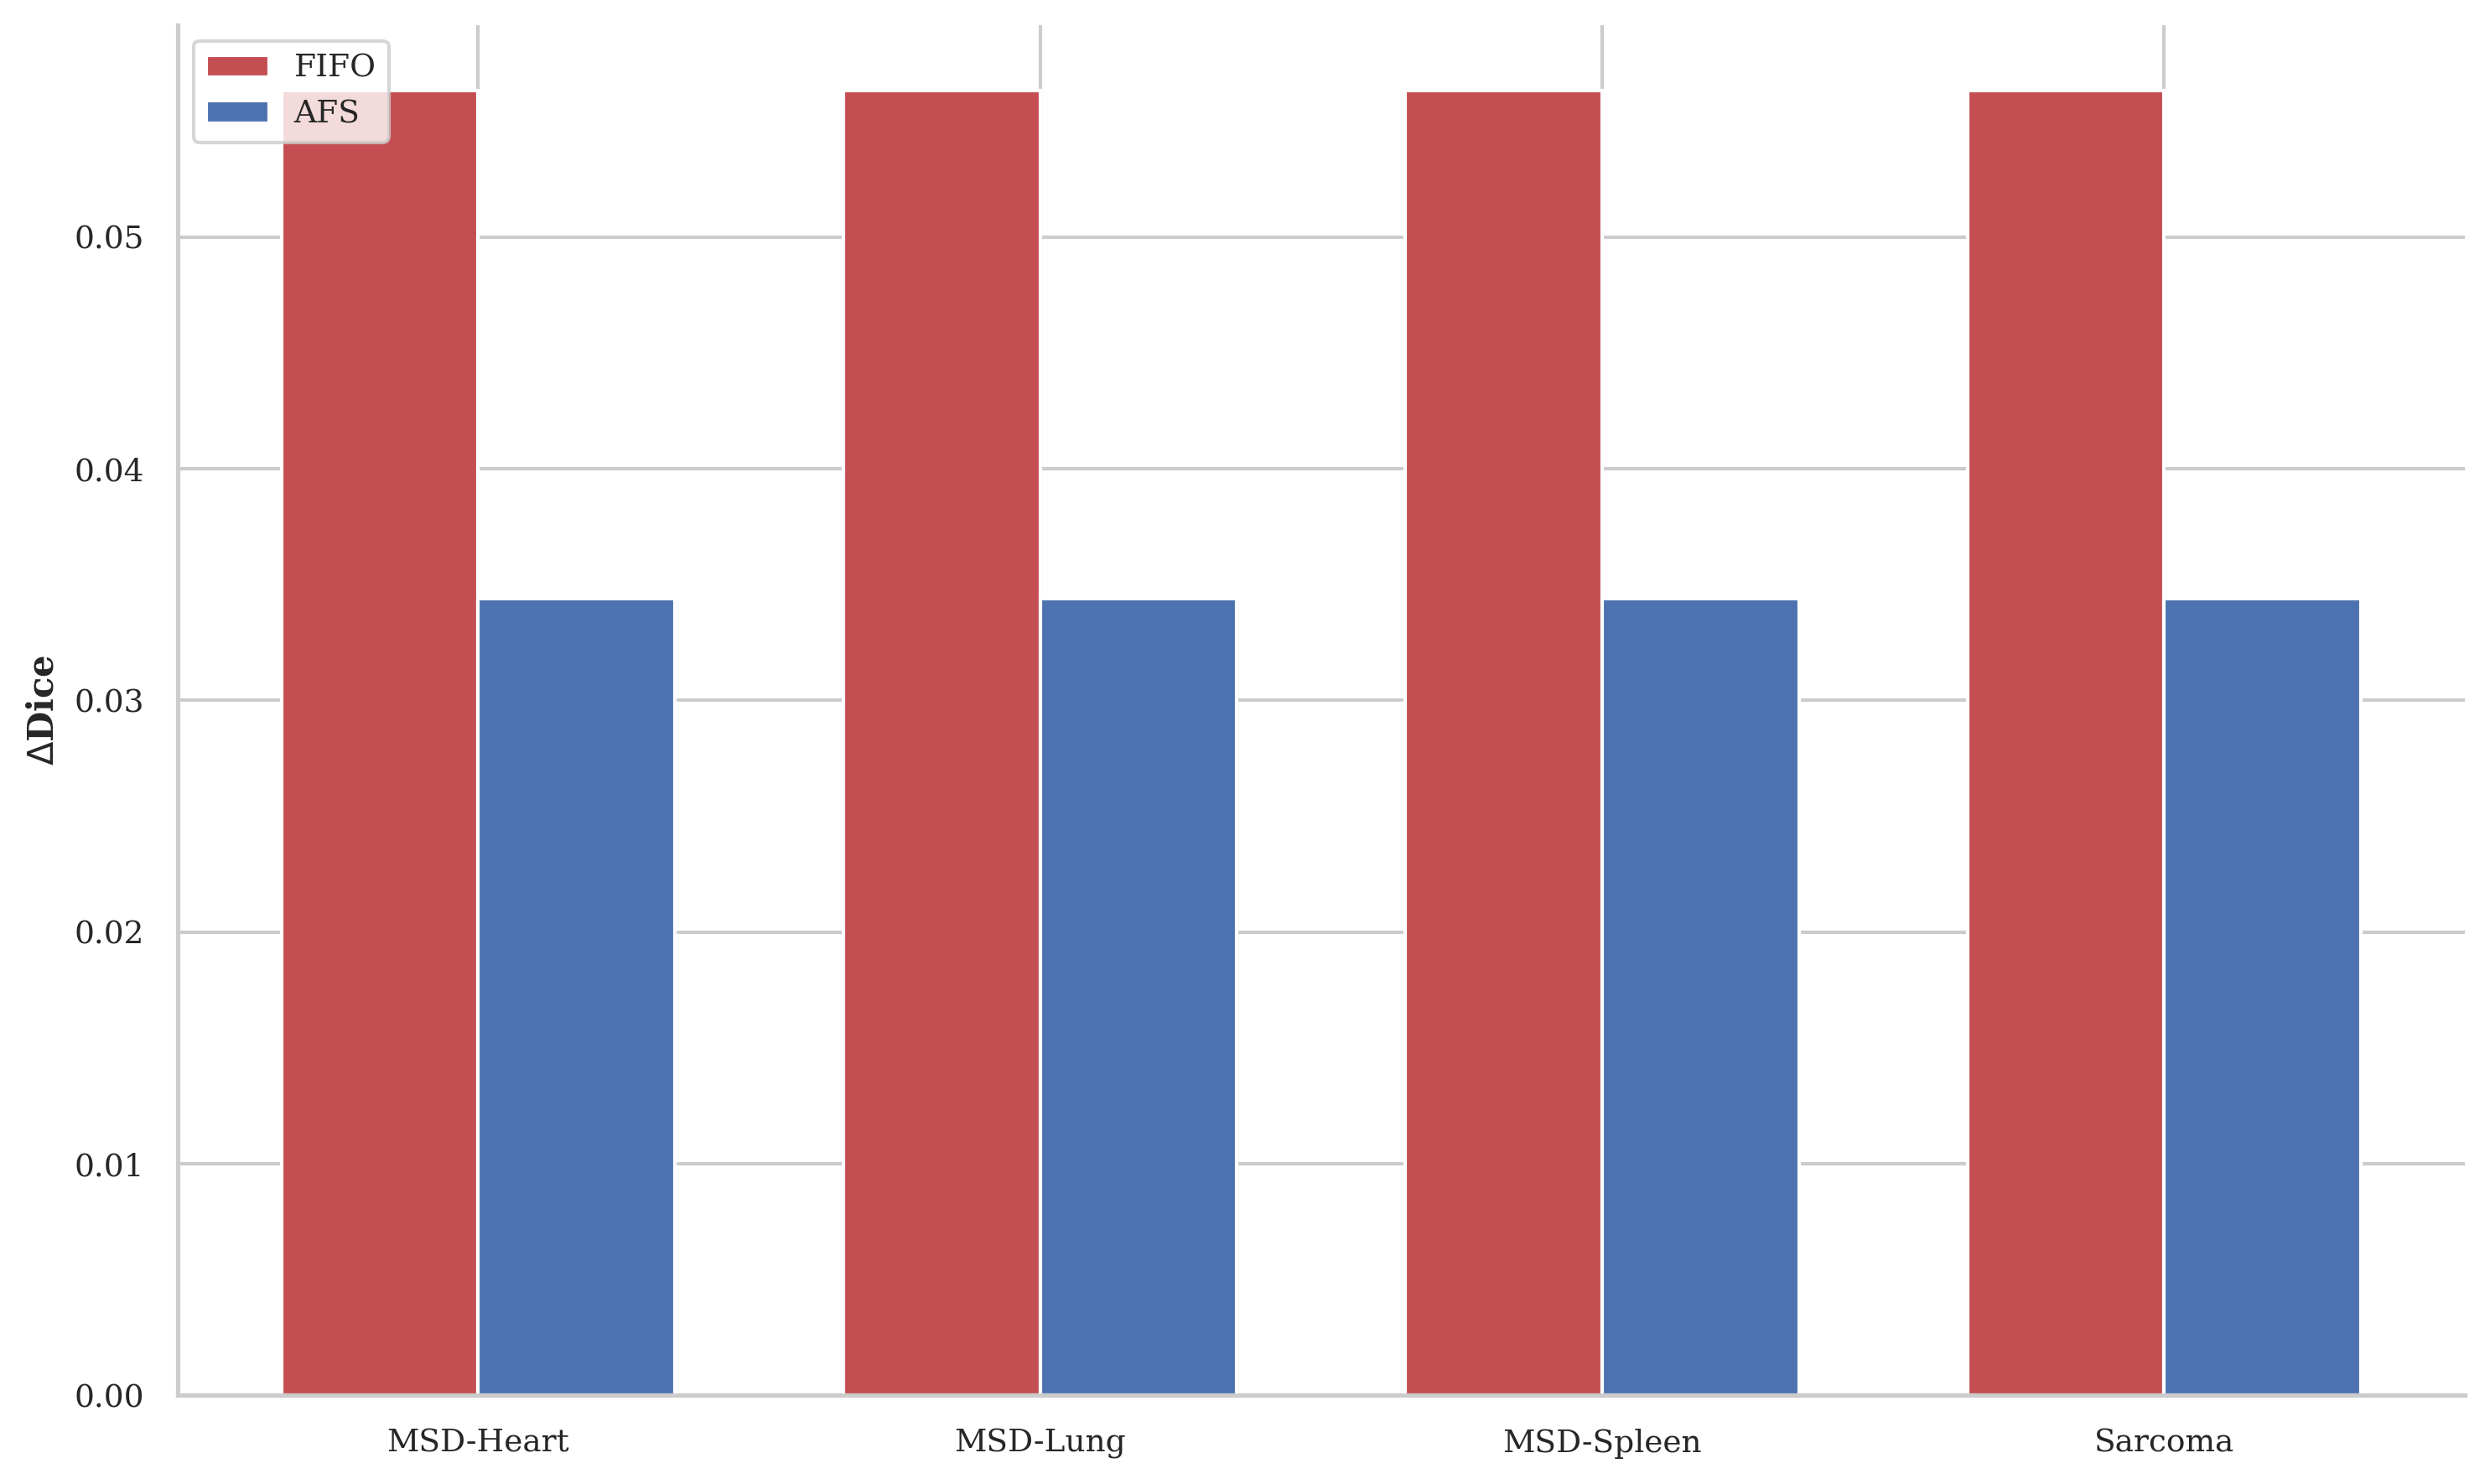

In [70]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#4C72B0", "#C44E52"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# Example data structure
datasets = ['MSD-Heart', 'MSD-Lung', 'MSD-Spleen', 'Sarcoma']
fifo_vals = [v.median() for k, v in mean_delta.items() if "FIFO" in k]
afs_vals = [v.median() for k, v in mean_delta.items() if "AFS" in k]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = range(len(datasets))

ax.bar([i - width/2 for i in x], fifo_vals, width, label='FIFO', color='r')
ax.bar([i + width/2 for i in x], afs_vals, width, label='AFS', color='b')
ax.set_ylabel(r'$\Delta$Dice') # LaTeX formatting
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(frameon=True, loc='upper left')
sns.despine() # Removes unnecessary top/right borders
plt.tight_layout()
# plt.savefig("output/quantitative.pdf")

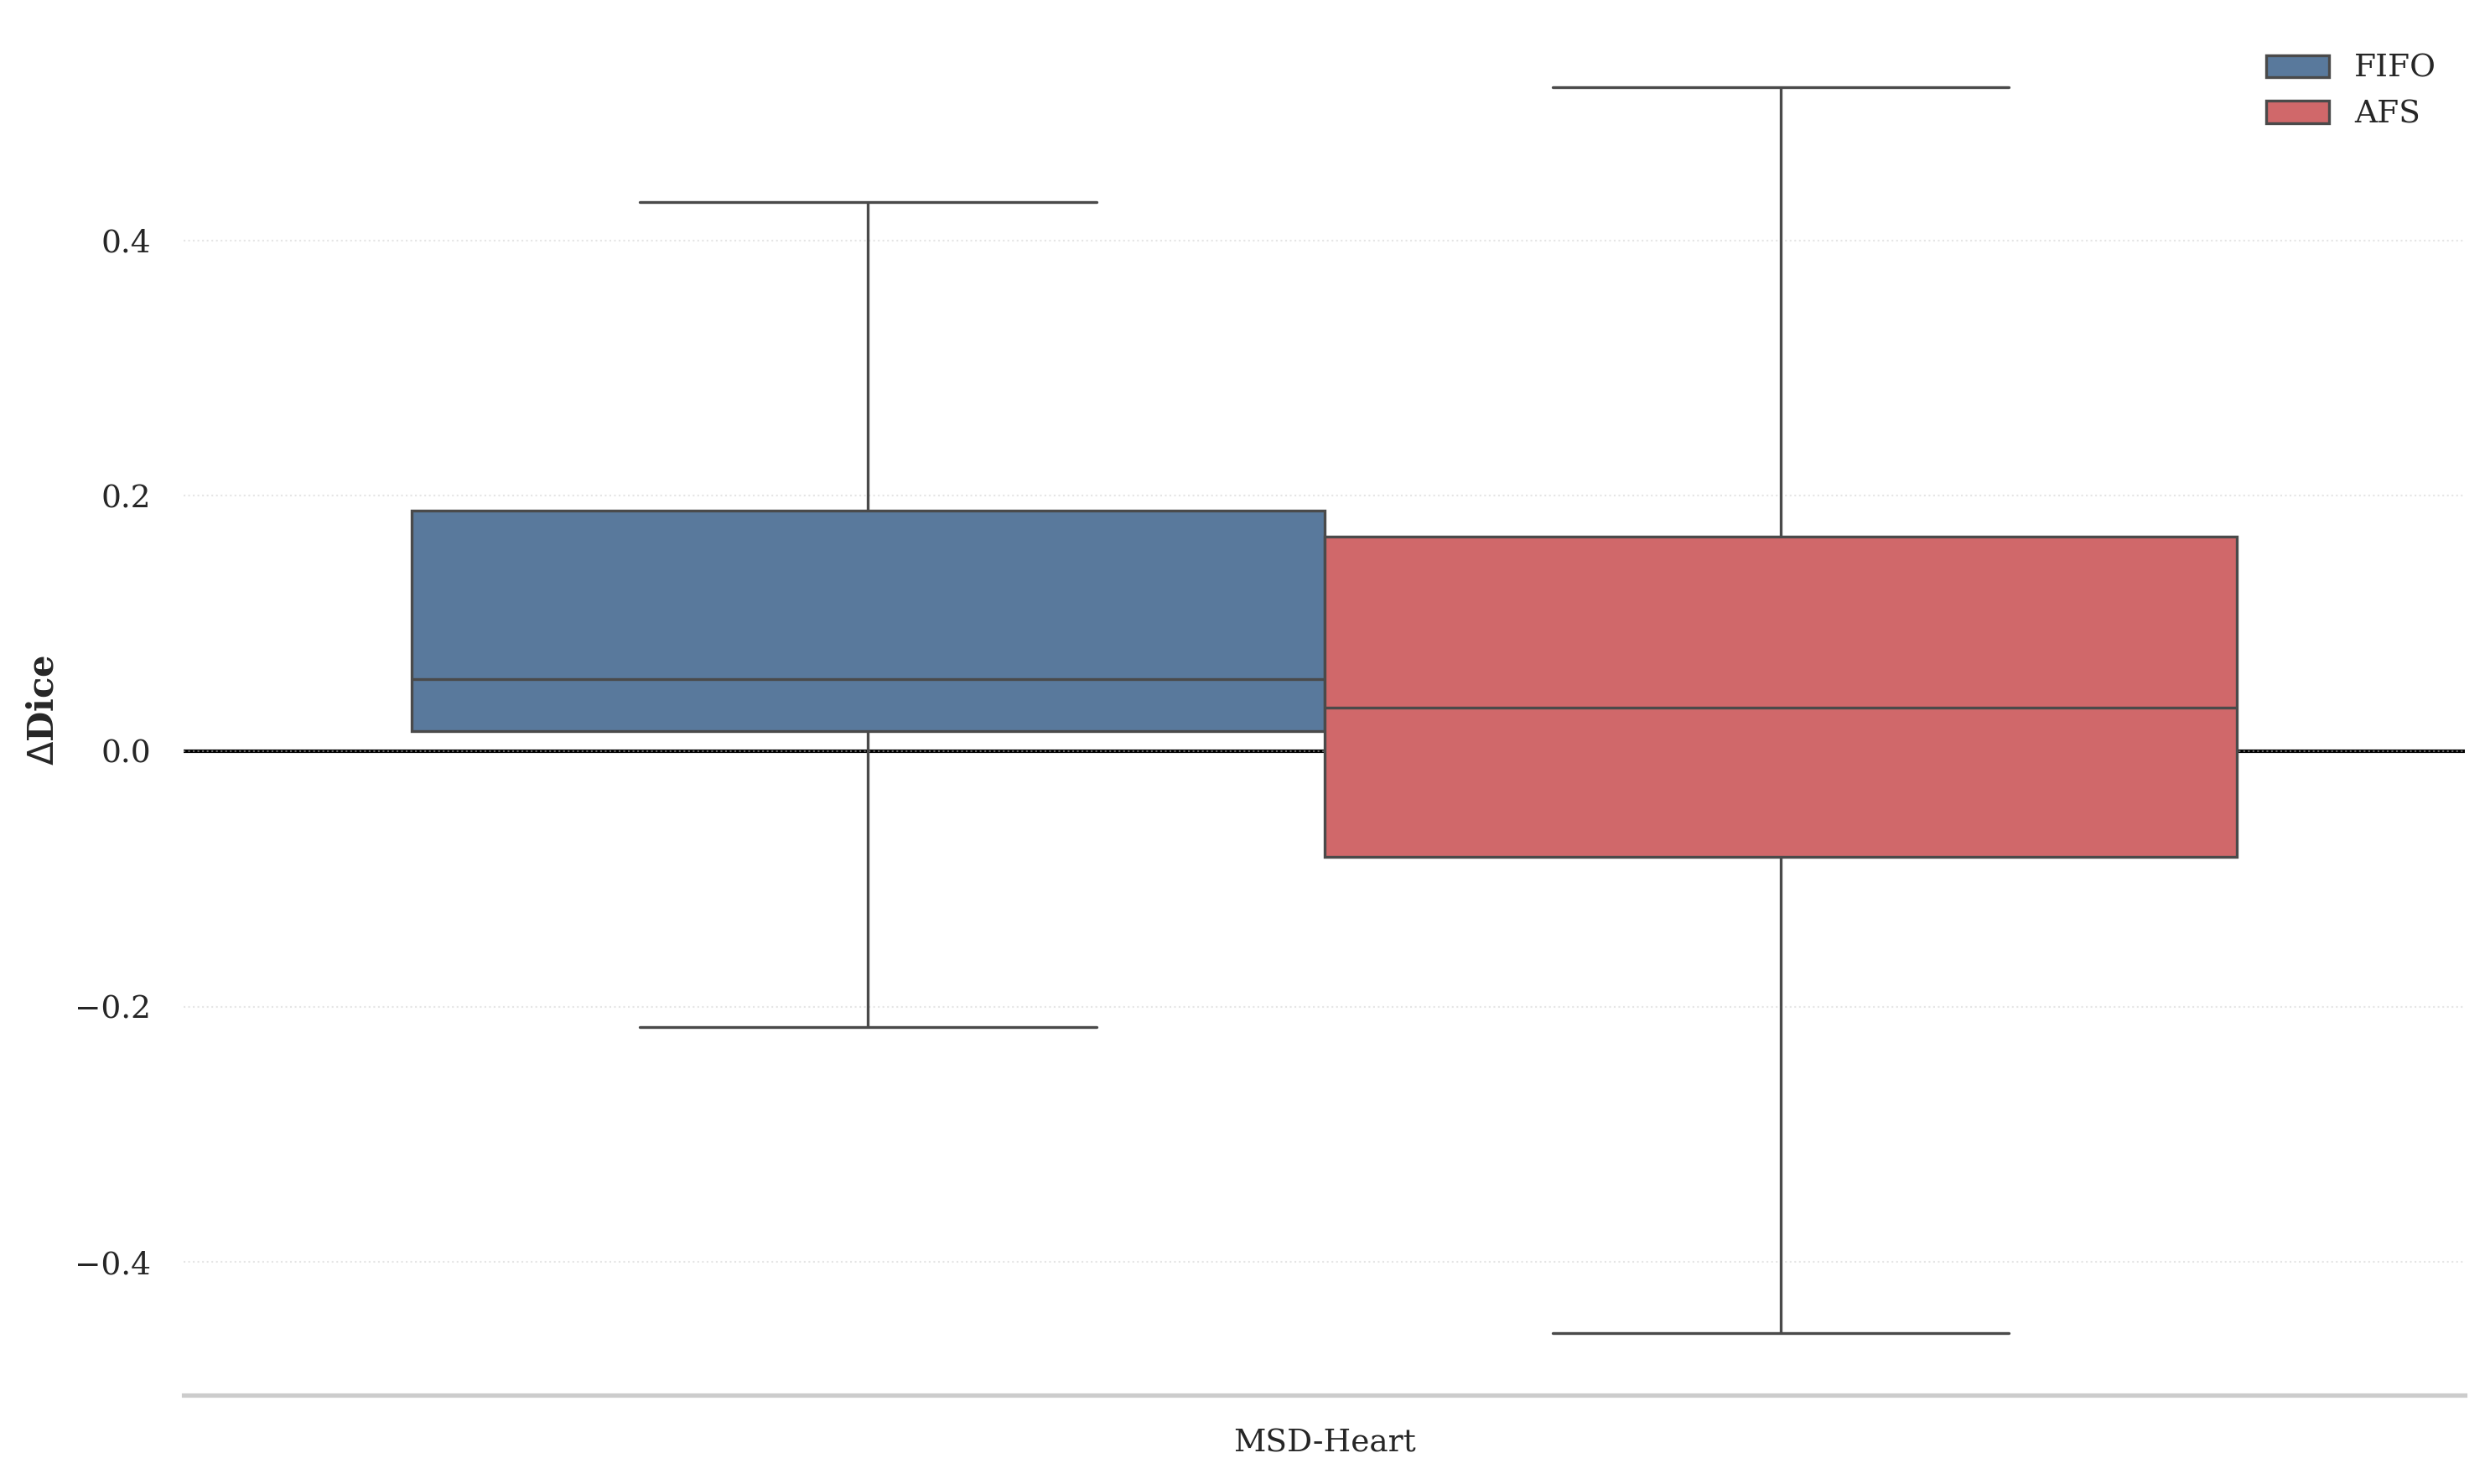

In [71]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#4C72B0", "#C44E52"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# 1. Setup synthetic data (simulating distributions around your previous means)
np.random.seed(42)
datasets = ['MSD-Heart']#, 'MSD-Lung', 'MSD-Spleen', 'Sarcoma']

data = []
# Means from your previous chart
fifo_means = [0.85, 2.9, 2.1, 1.45]
afs_means = [-0.1, 1.35, 0.3, 1.38]

for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data)

# 3. Create the Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Dataset',
    y='DeltaDice',
    hue='Method',
    palette=["#4e79a7", "#e15759"],
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
    showfliers=False, # Show outliers
    linewidth=0.8,
    ax=ax
)

# Professional tweaks
ax.axhline(0, color='black', linestyle='-', linewidth=1, zorder=0)
ax.set_ylabel(r'$\Delta$Dice')
ax.set_xlabel('') # Often dataset names on x-axis are self-explanatory
sns.despine(left=True) # Clean look
ax.grid(axis='y', linestyle=':', alpha=0.5, linewidth=0.5)
ax.set_axisbelow(True) # Ensure grid is behind the boxes
plt.legend(frameon=False, loc="best")
plt.tight_layout()

# Save as vector for final paper
# plt.savefig('output/quantitative-box.pdf', bbox_inches='tight')
# plt.show()

/tmp/ipykernel_1942751/300037499.py:50: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


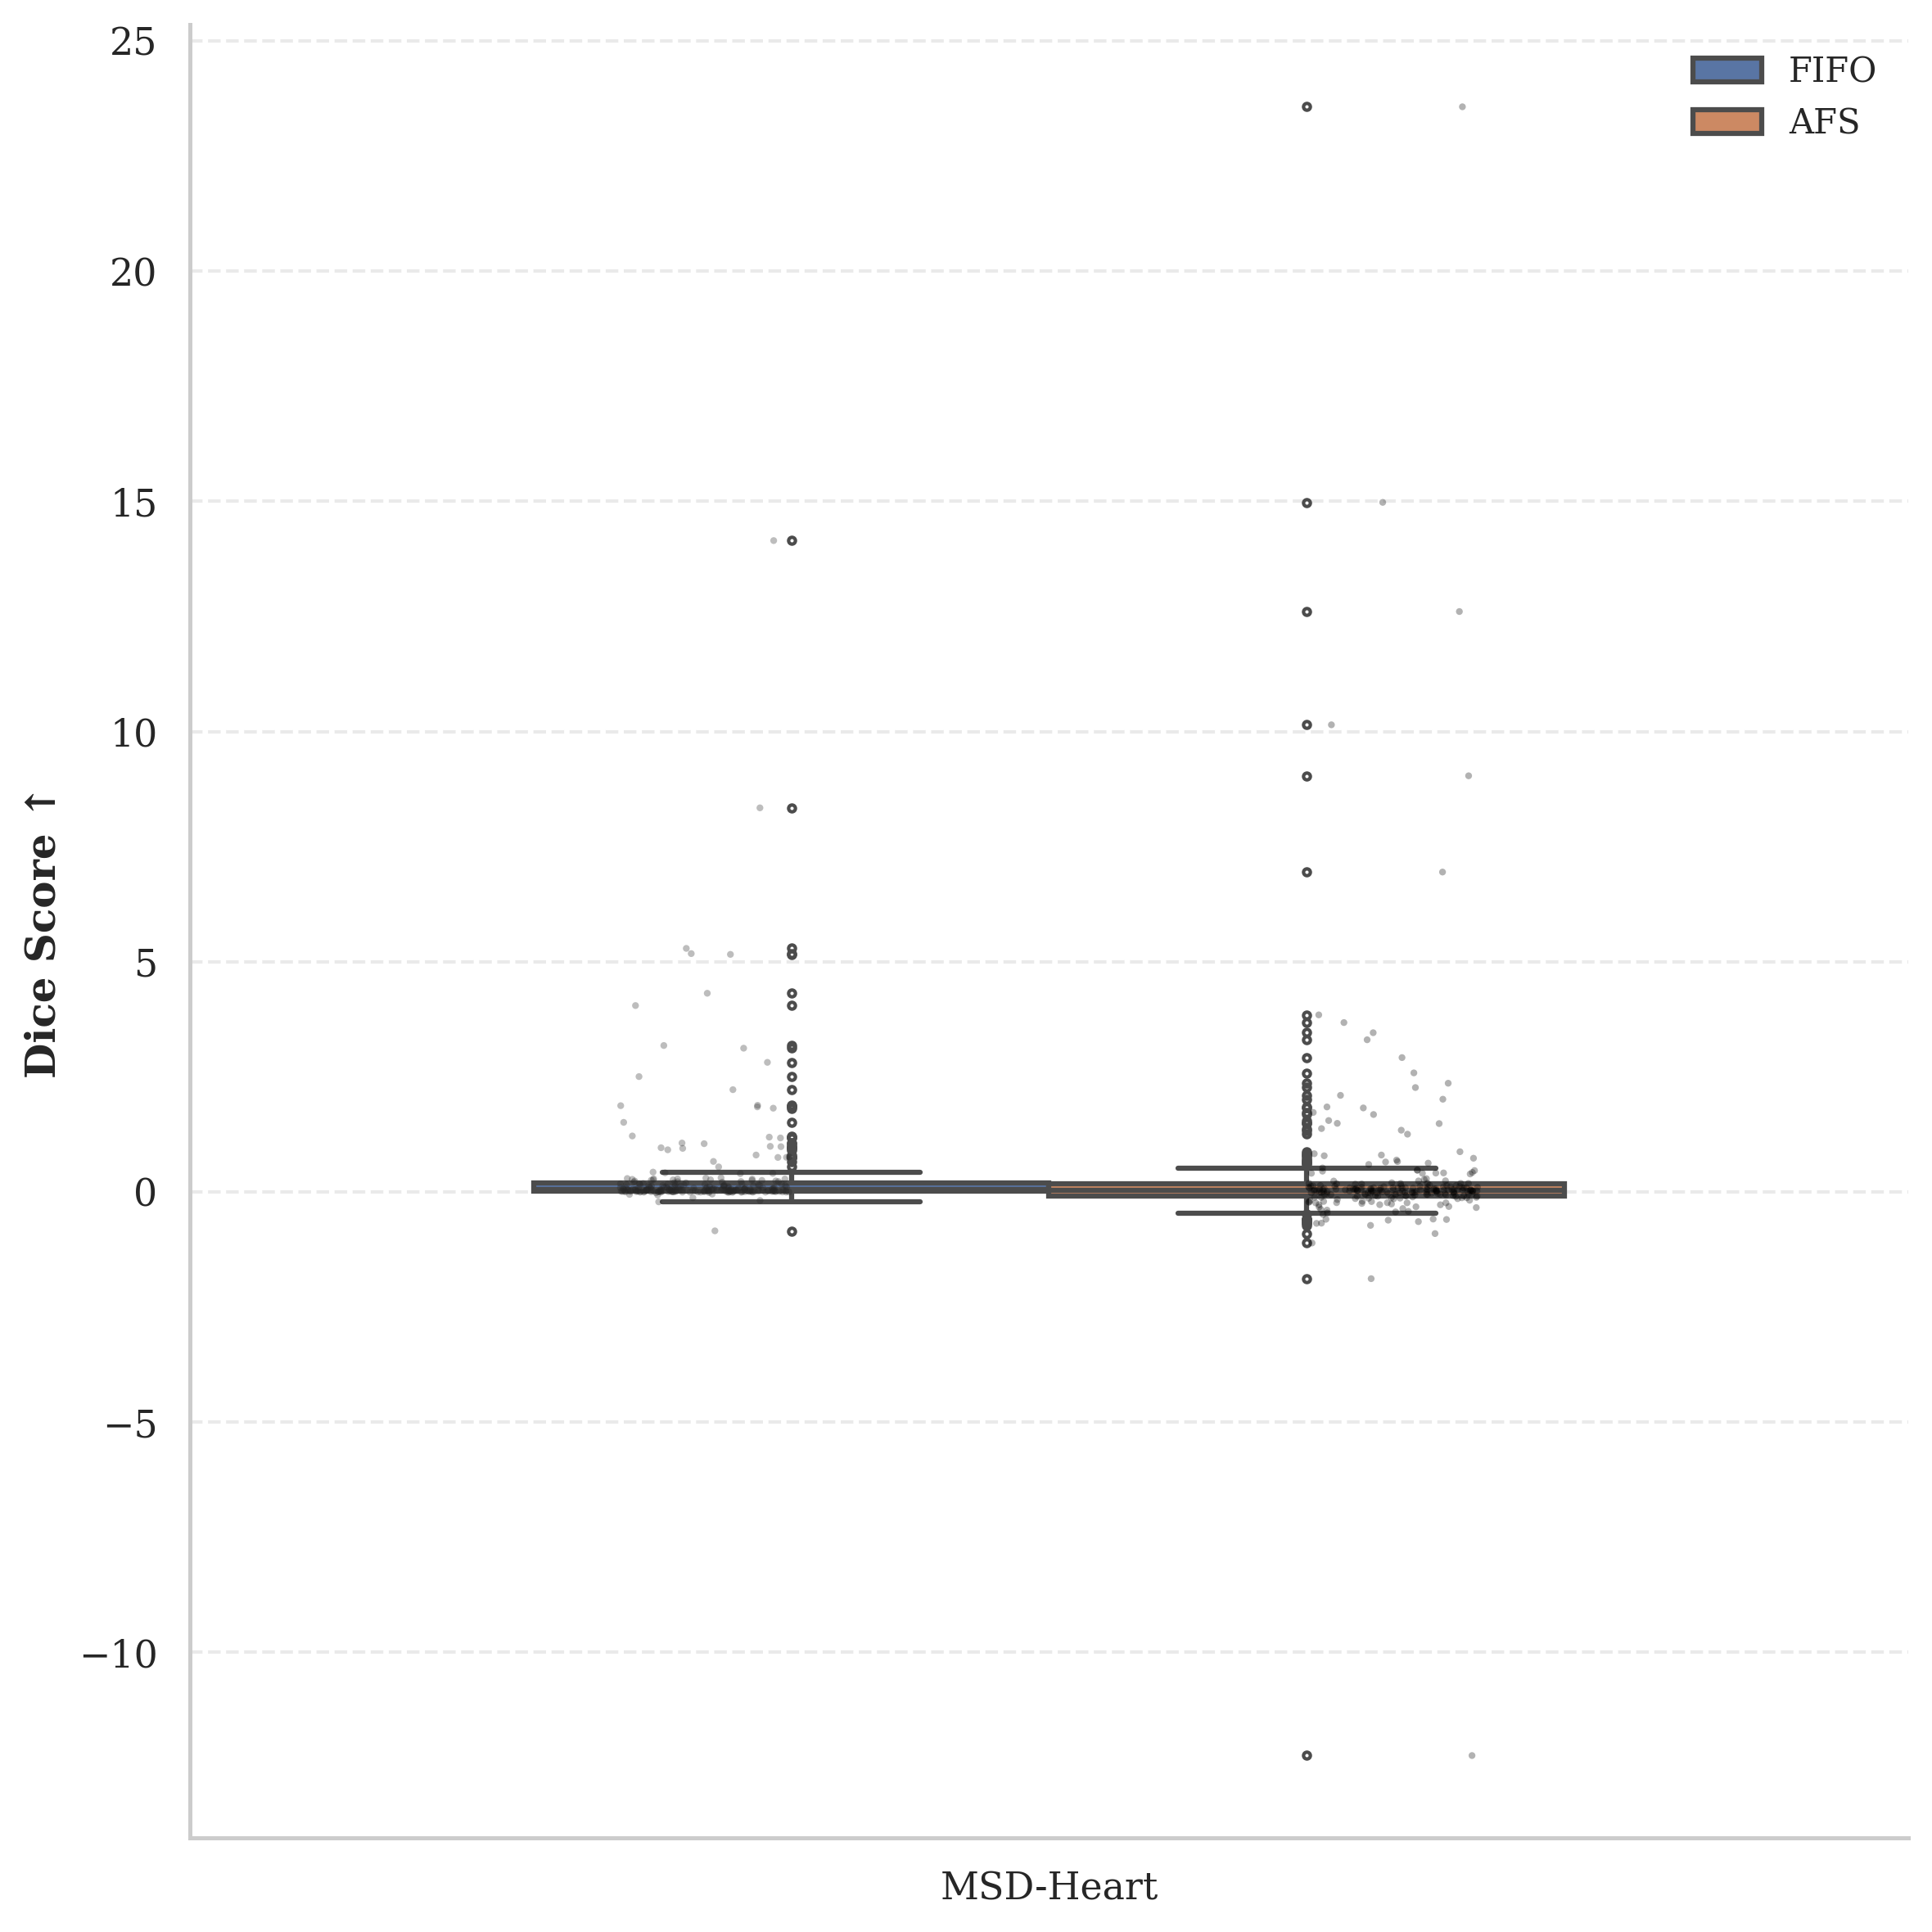

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---- GLOBAL STYLE ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,  # Editable text in Illustrator
    "ps.fonttype": 42,
})

# ---- Example Data Structure ----
# Replace with your real data
datasets = ["MSD-Heart"]#, "MSD-Lung", "MSD-Spleen", "Sarcoma"]
methods = ["FIFO", "AFS"]

data = []
for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data, columns=["Dataset", "Method", "DeltaDice"])

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 8))

palette = {
    "FIFO": "#4C72B0",
    "AFS": "#DD8452"
}

sns.boxplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    palette=palette,
    width=0.6,
    linewidth=1.5,
    fliersize=2,
    ax=ax
)

sns.stripplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    dodge=True,
    color="black",
    size=2,
    alpha=0.3,
    ax=ax
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], frameon=False, fontsize=10)

# Improve axis
ax.set_ylabel("Dice Score ↑", fontsize=12, weight="bold")
ax.set_xlabel("")
# ax.set_ylim(0.6, 0.95)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("quantitative_box_eccv.pdf", dpi=600, bbox_inches="tight")
plt.show()